In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] =(12,8)

df = pd.read_csv("movies.csv")

In [10]:
# import pandas as pd

# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 1000)

# df.head()

In [52]:
df.tail()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0
7667,Tee em el,NaN,Horror,2020,"August 19, 2020 (United States)",5.7,7.0,Pereko Mosia,Pereko Mosia,Siyabonga Mabaso,South Africa,NaN,NaN,PK 65 Films,102.0


In [4]:
# Let see if there is any missing data

for col in df.columns:
    pic_missing = np.mean(df[col].isnull())*100
    print('{} - {}%'.format(col,pic_missing))

name - 0.0%
rating - 1.004173187271779%
genre - 0.0%
year - 0.0%
released - 0.02608242044861763%
score - 0.03912363067292645%
votes - 0.03912363067292645%
director - 0.0%
writer - 0.03912363067292645%
star - 0.013041210224308816%
country - 0.03912363067292645%
budget - 28.31246739697444%
gross - 2.464788732394366%
company - 0.2217005738132499%
runtime - 0.05216484089723526%


In [5]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull()) * 100
    print(f'{col} - {pct_missing:.2f}%')

name - 0.00%
rating - 1.00%
genre - 0.00%
year - 0.00%
released - 0.03%
score - 0.04%
votes - 0.04%
director - 0.00%
writer - 0.04%
star - 0.01%
country - 0.04%
budget - 28.31%
gross - 2.46%
company - 0.22%
runtime - 0.05%


In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
display(missing_rows.head())

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
16,Fame,R,Drama,1980,"May 16, 1980 (United States)",6.6,21000.0,Alan Parker,Christopher Gore,Eddie Barth,United States,NaN,21202829.0,Metro-Goldwyn-Mayer (MGM),134.0
19,Stir Crazy,R,Comedy,1980,"December 12, 1980 (United States)",6.8,26000.0,Sidney Poitier,Bruce Jay Friedman,Gene Wilder,United States,NaN,101300000.0,Columbia Pictures,111.0
24,Urban Cowboy,PG,Drama,1980,"June 6, 1980 (United States)",6.4,14000.0,James Bridges,Aaron Latham,John Travolta,United States,NaN,46918287.0,Paramount Pictures,132.0
25,Altered States,R,Horror,1980,"December 25, 1980 (United States)",6.9,33000.0,Ken Russell,Paddy Chayefsky,William Hurt,United States,NaN,19853892.0,Warner Bros.,102.0
26,Little Darlings,R,Comedy,1980,"March 21, 1980 (United States)",6.5,5100.0,Ron Maxwell,Kimi Peck,Tatum O'Neal,United States,NaN,34326249.0,Stephen Friedman/Kings Road Productions,96.0


In [7]:
missing_rows = df[df.isnull().any(axis=1)]

missing_rows[[ 'budget' ]].head(8000)

,budget
16,NaN
19,NaN
24,NaN
25,NaN
26,NaN
...,...
7663,7000.0
7664,NaN
7665,58750.0
7666,15000.0


In [9]:
df.isnull().sum().sum()

2473

In [53]:
missing_count = df.isnull().sum()

missing_count = missing_count[missing_count > 0]

print(missing_count.sort_values(ascending=False))

budget      2171
gross        189
rating        77
company       17
runtime        4
score          3
votes          3
writer         3
country        3
released       2
star           1
dtype: int64


In [12]:
df=df.dropna(subset=[
    'rating',      
    'company',       
    'runtime',        
    'score',          
    'votes',          
    'writer',         
    'country',      
    'released',       
    'star'        
])

In [55]:
df['budget'] = df['budget'].fillna(df['budget'].median())

In [56]:
df=df.dropna(subset=['gross'])

In [57]:
#Data types of the column

df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [58]:
# df['budget'] = df['budget'].astype('int64')
# df['gross'] = df['gross'].astype('int64')
# df['votes'] = df['votes'].astype('int64')

df[['budget','gross','votes']].isnull().sum()

budget    0
gross     0
votes     0
dtype: int64

In [40]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Correct_year
0,The Shining,R,Drama,1980,1980-06-13 00:00:00,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,1980-07-02 00:00:00,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20 00:00:00,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,1980-07-02 00:00:00,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,1980-07-25 00:00:00,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7651,The Call of the Wild,PG,Adventure,2020,2020-02-21 00:00:00,6.8,42000,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0,2020
7652,The Eight Hundred,Not Rated,Action,2020,2020-08-28 00:00:00,6.8,3700,Hu Guan,Hu Guan,Zhi-zhong Huang,China,80000000,461421559,Beijing Diqi Yinxiang Entertainment,149.0,2020
7653,The Quarry,R,Crime,2020,2020-04-17 00:00:00,5.4,2400,Scott Teems,Scott Teems,Shea Whigham,United States,21000000,3661,Prowess Pictures,98.0,2020
7656,Tulsa,PG-13,Comedy,2020,2020-06-03 00:00:00,5.0,294,Scott Pryor,Scott Pryor,Scott Pryor,United States,21000000,413378,Pryor Entertainment,120.0,2020


In [18]:
df['released'].astype(str)

0           June 13, 1980 (United States)
1            July 2, 1980 (United States)
2           June 20, 1980 (United States)
3            July 2, 1980 (United States)
4           July 25, 1980 (United States)
                      ...                
7651    February 21, 2020 (United States)
7652      August 28, 2020 (United States)
7653              April 17, 2020 (Mexico)
7656         June 3, 2020 (United States)
7659        March 3, 2020 (United States)
Name: released, Length: 7412, dtype: object

In [19]:
#Removing the state name from the release date
df['released'] = df['released'].str.split('(').str[0]

In [20]:
# Convert to datetime
df['released'] = pd.to_datetime(df['released'])

In [21]:
# Change format to MM-DD-YY
df['released'] = df['released'].dt.strftime('m%-d%-y%')

In [22]:
# Createing the new year colunm
df['Correct_year'] = df['released'].astype(str).str[0:4]

In [59]:
# df.sort_values(by=['gross'],inplace = False,ascending=False)
df=df.sort_values(by=['gross'],inplace = False,ascending=False)

In [44]:
# Creates the sliding bar in the sides
pd.set_option('display.max_rows',None)

In [23]:
#Drop the dulicate value
# df['company'].drop_duplicates().sort_values(ascending = False)
# df.duplicated().sum()
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Correct_year
0,The Shining,R,Drama,1980,1980-06-13 00:00:00,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,1980-07-02 00:00:00,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20 00:00:00,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,1980-07-02 00:00:00,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,1980-07-25 00:00:00,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7651,The Call of the Wild,PG,Adventure,2020,2020-02-21 00:00:00,6.8,42000,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0,2020
7652,The Eight Hundred,Not Rated,Action,2020,2020-08-28 00:00:00,6.8,3700,Hu Guan,Hu Guan,Zhi-zhong Huang,China,80000000,461421559,Beijing Diqi Yinxiang Entertainment,149.0,2020
7653,The Quarry,R,Crime,2020,2020-04-17 00:00:00,5.4,2400,Scott Teems,Scott Teems,Shea Whigham,United States,21000000,3661,Prowess Pictures,98.0,2020
7656,Tulsa,PG-13,Comedy,2020,2020-06-03 00:00:00,5.0,294,Scott Pryor,Scott Pryor,Scott Pryor,United States,21000000,413378,Pryor Entertainment,120.0,2020


In [ ]:
# Budget high correlation
# Company high correlation

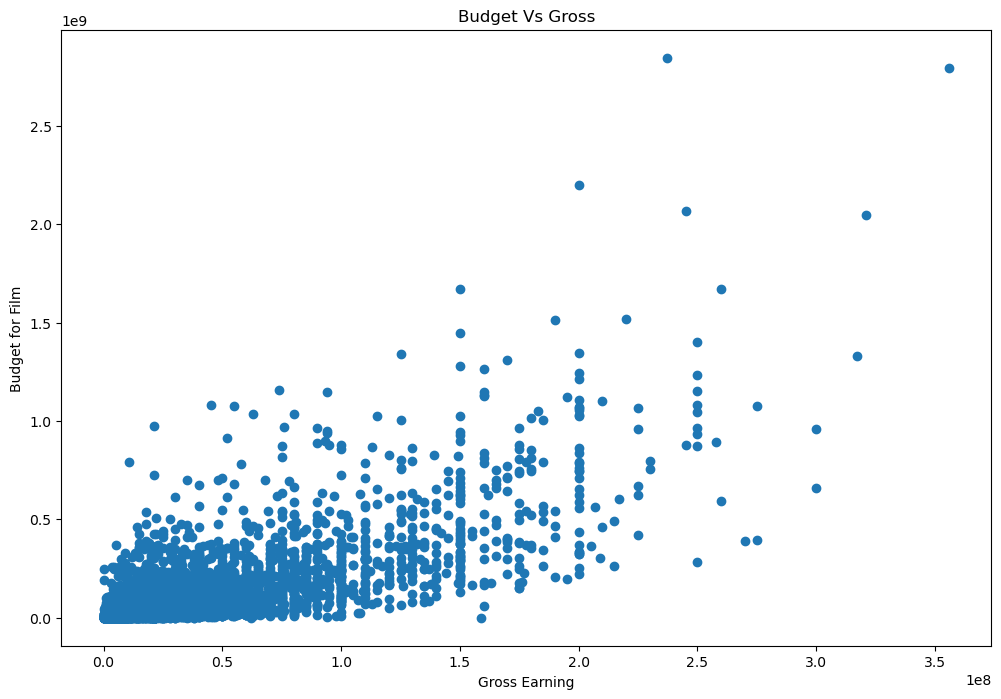

In [24]:
# Scatter plot with budget and gross
plt.scatter(x=df['budget'],y=df['gross'])
plt.title("Budget Vs Gross")
plt.xlabel("Gross Earning")
plt.ylabel("Budget for Film")
plt.show()

In [25]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Correct_year
0,The Shining,R,Drama,1980,1980-06-13 00:00:00,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,1980-07-02 00:00:00,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20 00:00:00,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,1980-07-02 00:00:00,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,1980-07-25 00:00:00,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980


<AxesSubplot:xlabel='budget', ylabel='gross'>

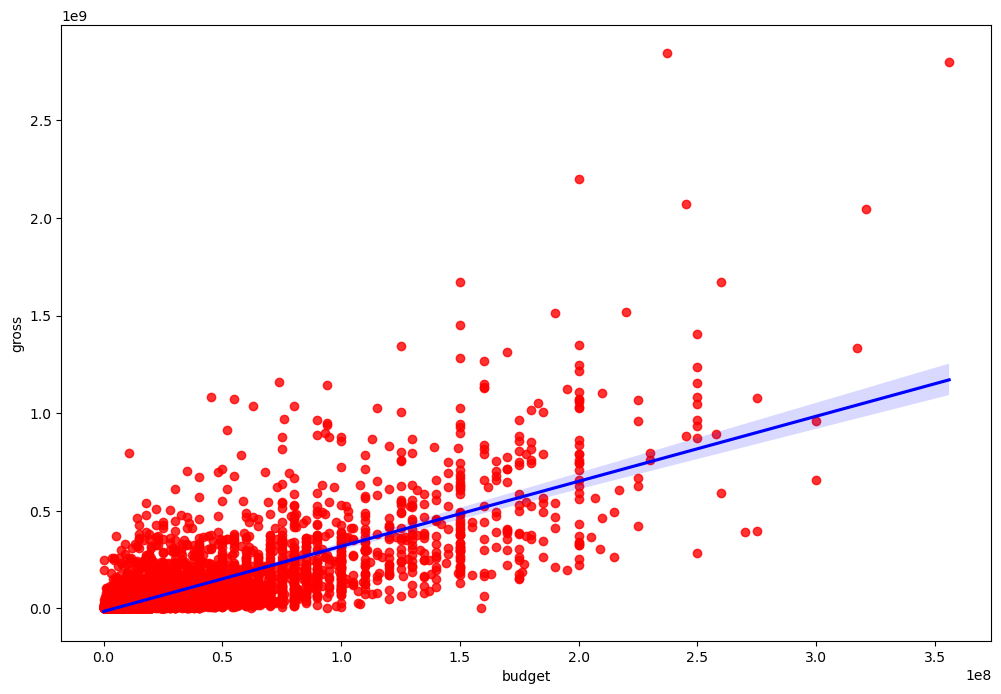

In [19]:
# Plot with budget and gross using seaborn
sns.regplot(x='budget',y='gross',data=df,scatter_kws={"color":"red"},line_kws={"color":"blue"})

In [26]:
df.corr(method='spearman') # kendall,pearson,spearman

,year,score,votes,budget,gross,runtime
year,1.000000,0.095848,0.465166,0.258815,0.297499,0.133069
score,0.095848,1.000000,0.434803,-0.009292,0.129759,0.398280
votes,0.465166,0.434803,1.000000,0.385171,0.743122,0.281526
budget,0.258815,-0.009292,0.385171,1.000000,0.528900,0.271029
gross,0.297499,0.129759,0.743122,0.528900,1.000000,0.246503
runtime,0.133069,0.398280,0.281526,0.271029,0.246503,1.000000


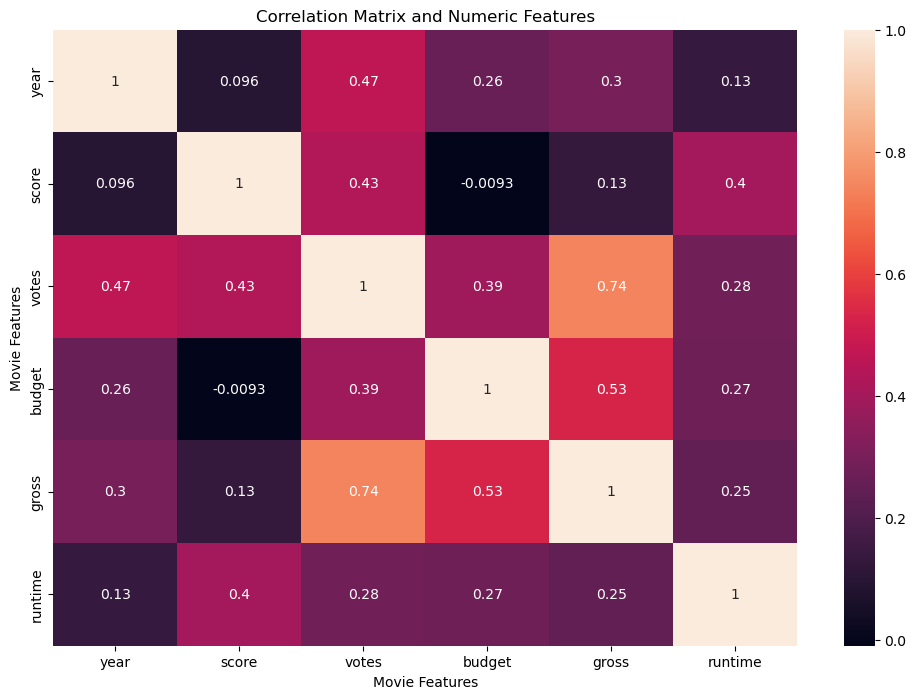

In [27]:
# High correlation between budget and gross

high_correlation =df.corr(method='spearman')

sns.heatmap(high_correlation,annot=True)
plt.title("Correlation Matrix and Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show()

In [62]:
df_numerized = df

for col in df_numerized.columns:
    if(df_numerized[col].dtype == 'object'):
        df_numerized[col] = df_numerized[col].astype('category')
        df_numerized[col] = df_numerized[col].cat.codes
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,519,5,0,2009,683,7.8,1100000.0,1116,1719,2233,53,237000000.0,2.847246e+09,2148,162.0
7445,521,5,0,2019,179,8.4,903000.0,161,717,2141,53,356000000.0,2.797501e+09,1532,181.0
3045,6727,5,6,1997,691,7.8,1100000.0,1116,1719,1524,53,200000000.0,2.201647e+09,2148,194.0
6663,5008,5,0,2015,685,7.8,876000.0,1086,2468,504,53,245000000.0,2.069522e+09,1470,138.0
7244,522,5,0,2018,188,8.4,897000.0,161,717,2141,53,321000000.0,2.048360e+09,1532,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3268,6,4,2000,1097,6.5,5200.0,711,1085,2218,52,20500000.0,1.400000e+03,463,103.0
7625,6559,-1,4,2019,1125,5.7,320.0,2459,2483,1830,53,20500000.0,7.900000e+02,2202,104.0
7580,4540,3,5,2019,1796,5.2,735.0,1403,2135,2177,53,20500000.0,6.820000e+02,1901,93.0
2417,3309,-1,6,1993,83,7.3,5100.0,33,1660,2453,27,11900000.0,5.960000e+02,764,134.0


In [60]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000.0,2.847246e+09,Twentieth Century Fox,162.0
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,United Kingdom,20500000.0,1.400000e+03,British Broadcasting Corporation (BBC),103.0
7625,The Untold Story,NaN,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,United States,20500000.0,7.900000e+02,Visual Arts Entertainment,104.0
7580,Run with the Hunted,Not Rated,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,United States,20500000.0,6.820000e+02,Roxwell Films,93.0
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000.0,5.960000e+02,DENTSU Music And Entertainment,134.0


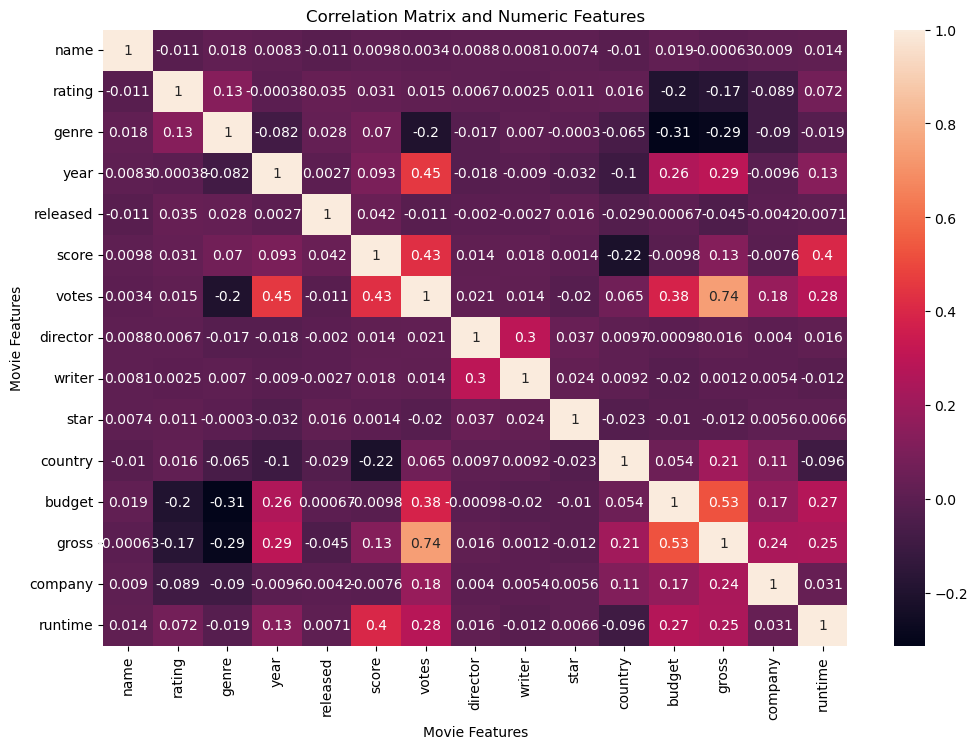

In [63]:

high_correlation =df_numerized.corr(method='spearman')

sns.heatmap(high_correlation,annot=True)
plt.title("Correlation Matrix and Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show()

In [64]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
name,1.000000,-0.006091,0.017885,0.007404,-0.011033,0.015473,0.011429,0.009092,0.008008,0.007278,-0.012027,0.020081,0.005557,0.008155,0.009142
rating,-0.006091,1.000000,0.087325,0.012776,0.022026,0.002766,0.028082,0.014723,-0.006793,0.004774,0.066465,-0.120989,-0.107339,-0.052477,0.059870
genre,0.017885,0.087325,1.000000,-0.082252,0.026804,0.046093,-0.149289,-0.016412,0.008231,-0.002322,-0.033283,-0.337894,-0.243059,-0.074570,-0.041023
year,0.007404,0.012776,-0.082252,1.000000,0.002465,0.091821,0.215740,-0.019116,-0.008780,-0.032319,-0.084488,0.289548,0.257486,-0.014883,0.114706
released,-0.011033,0.022026,0.026804,0.002465,1.000000,0.044301,0.018043,-0.002315,-0.002699,0.015812,-0.020083,0.014129,0.002341,-0.007031,0.000605
score,0.015473,0.002766,0.046093,0.091821,0.044301,1.000000,0.413096,0.008810,0.018648,0.000310,-0.129474,0.058121,0.186258,-0.001107,0.397321
votes,0.011429,0.028082,-0.149289,0.215740,0.018043,0.413096,1.000000,0.000919,0.000972,-0.021274,0.069934,0.458372,0.630757,0.131020,0.309536
director,0.009092,0.014723,-0.016412,-0.019116,-0.002315,0.008810,0.000919,1.000000,0.297601,0.036794,0.014435,-0.001834,-0.014490,0.004213,0.016942
writer,0.008008,-0.006793,0.008231,-0.008780,-0.002699,0.018648,0.000972,0.297601,1.000000,0.023374,0.011871,-0.030693,-0.023574,0.005972,-0.002816
star,0.007278,0.004774,-0.002322,-0.032319,0.015812,0.000310,-0.021274,0.036794,0.023374,1.000000,-0.016192,-0.020173,-0.002602,0.007518,0.009227


In [66]:
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack()
corr_pairs

name     name        1.000000
         rating     -0.006091
         genre       0.017885
         year        0.007404
         released   -0.011033
                       ...   
runtime  country    -0.078174
         budget      0.272963
         gross       0.245216
         company     0.031255
         runtime     1.000000
Length: 225, dtype: float64

In [67]:
pd.set_option('display.max_rows', None)


In [68]:
print(corr_pairs)

name      name        1.000000
          rating     -0.006091
          genre       0.017885
          year        0.007404
          released   -0.011033
          score       0.015473
          votes       0.011429
          director    0.009092
          writer      0.008008
          star        0.007278
          country    -0.012027
          budget      0.020081
          gross       0.005557
          company     0.008155
          runtime     0.009142
rating    name       -0.006091
          rating      1.000000
          genre       0.087325
          year        0.012776
          released    0.022026
          score       0.002766
          votes       0.028082
          director    0.014723
          writer     -0.006793
          star        0.004774
          country     0.066465
          budget     -0.120989
          gross      -0.107339
          company    -0.052477
          runtime     0.059870
genre     name        0.017885
          rating      0.087325
        

In [70]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

genre     budget     -0.337894
budget    genre      -0.337894
genre     gross      -0.243059
gross     genre      -0.243059
genre     votes      -0.149289
votes     genre      -0.149289
score     country    -0.129474
country   score      -0.129474
rating    budget     -0.120989
budget    rating     -0.120989
gross     rating     -0.107339
rating    gross      -0.107339
year      country    -0.084488
country   year       -0.084488
genre     year       -0.082252
year      genre      -0.082252
country   runtime    -0.078174
runtime   country    -0.078174
genre     company    -0.074570
company   genre      -0.074570
          rating     -0.052477
rating    company    -0.052477
genre     runtime    -0.041023
runtime   genre      -0.041023
country   genre      -0.033283
genre     country    -0.033283
star      year       -0.032319
year      star       -0.032319
writer    budget     -0.030693
budget    writer     -0.030693
writer    gross      -0.023574
gross     writer     -0.023574
votes   

In [72]:
high_corr =sorted_pairs[(sorted_pairs > 0.5)]
high_corr

gross     votes       0.630757
votes     gross       0.630757
budget    gross       0.745552
gross     budget      0.745552
name      name        1.000000
director  director    1.000000
gross     gross       1.000000
budget    budget      1.000000
country   country     1.000000
star      star        1.000000
writer    writer      1.000000
votes     votes       1.000000
score     score       1.000000
released  released    1.000000
year      year        1.000000
genre     genre       1.000000
rating    rating      1.000000
company   company     1.000000
runtime   runtime     1.000000
dtype: float64